In [1]:
# 1. Import the libraries and check if the GPU is available.
# Use the .venv kernel; for a fresh setup: %pip install -r requirements-notebook.txt
# Data/model libraries are fine; compression logic will be our own code.
import sys
import json
import random
import platform
from pathlib import Path
from functools import partial
from importlib.metadata import version

import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from torchvision.models import mobilenet_v2

print("Python:", sys.executable)
print("torch:", torch.__version__, "| torchvision:", torchvision.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", torch.cuda.get_device_name(0) if device.type == "cuda" else "CPU")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

Python: C:\Users\ASUS\Desktop\my_files\Courses\SEM-7\SE for DL\Assignments\Assignment-2\.venv\Scripts\python.exe
torch: 2.14.0+cu126 | torchvision: 0.29.0+cu126
Using: NVIDIA GeForce RTX 3050 Laptop GPU


In [2]:
# 2. Set the batch size, folders and seeds for repeatable runs.
seed = 42
batch_size = 32
val_per_class = 500
num_workers = 0   # keeping it simple on Windows
image_size = 32
width_mult = 1.0
dropout = 0.2

project_dir = Path.cwd()
assert (project_dir / "cifar10_mobilenetv2_exploration.ipynb").exists(), "Run from the assignment folder."
data_dir = project_dir / "data"
save_dir = project_dir / "artifacts" / "preparation"
data_dir.mkdir(exist_ok=True)
save_dir.mkdir(parents=True, exist_ok=True)

# same seed, so the split doesn't keep changing
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

In [3]:
# 3. Load CIFAR-10 and check its labels, shape and pixel range.
# Dataset reference: https://cave.cs.toronto.edu/kriz/cifar.html
raw_train = datasets.CIFAR10(root=str(data_dir), train=True, download=True)
raw_test = datasets.CIFAR10(root=str(data_dir), train=False, download=True)

classes = raw_train.classes
num_classes = len(classes)
all_train_labels = np.array(raw_train.targets)

print("Train:", len(raw_train), "| Test:", len(raw_test))
print("Shape:", raw_train.data.shape, "| dtype:", raw_train.data.dtype)
print("Pixel range:", raw_train.data.min(), "to", raw_train.data.max())
print(dict(enumerate(classes)))

Train: 50000 | Test: 10000
Shape: (50000, 32, 32, 3) | dtype: uint8
Pixel range: 0 to 255
{0: 'airplane', 1: 'automobile', 2: 'bird', 3: 'cat', 4: 'deer', 5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'}


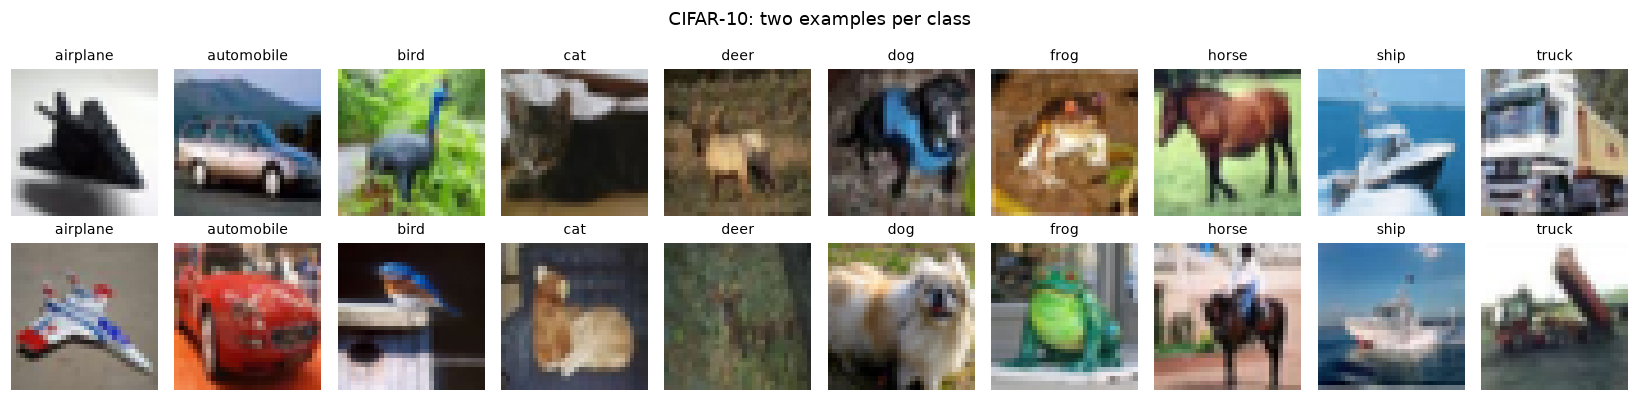

In [4]:
# 4. Plot two images from each class to see what we are working with.
fig, axes = plt.subplots(2, num_classes, figsize=(15, 3.8))
for class_id, class_name in enumerate(classes):
    example_indices = np.flatnonzero(all_train_labels == class_id)[:2]
    for row, image_index in enumerate(example_indices):
        axes[row, class_id].imshow(raw_train.data[image_index])
        axes[row, class_id].set_title(class_name, fontsize=9)
        axes[row, class_id].axis("off")
fig.suptitle("CIFAR-10: two examples per class")
plt.tight_layout()
plt.show()

Our split: train=45,000, validation=5,000, test=10,000


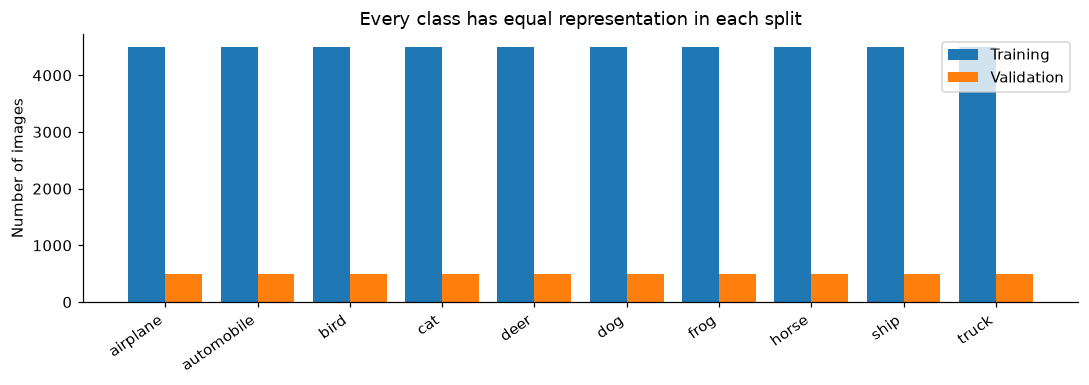

In [5]:
# 5. Keep 4500 train + 500 val images per class; the 10k test images stay separate.
split_rng = np.random.default_rng(seed)
train_parts, val_parts = [], []

for class_id in range(num_classes):
    class_indices = np.flatnonzero(all_train_labels == class_id)
    shuffled = split_rng.permutation(class_indices)
    val_parts.append(shuffled[:val_per_class])
    train_parts.append(shuffled[val_per_class:])

train_indices = split_rng.permutation(np.concatenate(train_parts))
val_indices = split_rng.permutation(np.concatenate(val_parts))

assert len(np.intersect1d(train_indices, val_indices)) == 0

train_counts = np.bincount(all_train_labels[train_indices], minlength=num_classes)
val_counts = np.bincount(all_train_labels[val_indices], minlength=num_classes)

print(f"Our split: train={len(train_indices):,}, validation={len(val_indices):,}, test={len(raw_test):,}")

positions = np.arange(num_classes)
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.bar(positions - 0.2, train_counts, width=0.4, label="Training")
ax.bar(positions + 0.2, val_counts, width=0.4, label="Validation")
ax.set_xticks(positions, classes, rotation=35, ha="right")
ax.set_ylabel("Number of images")
ax.set_title("Every class has equal representation in each split")
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# 6. Calculate RGB mean/std from training images only, in small chunks to save RAM.
channel_sum = np.zeros(3, dtype=np.float64)
channel_squared_sum = np.zeros(3, dtype=np.float64)
pixels_per_channel = 0

for start in range(0, len(train_indices), 256):
    indices = train_indices[start:start + 256]
    pixels = raw_train.data[indices].astype(np.float64) / 255.0
    channel_sum += pixels.sum(axis=(0, 1, 2))
    channel_squared_sum += np.square(pixels).sum(axis=(0, 1, 2))
    pixels_per_channel += pixels.shape[0] * pixels.shape[1] * pixels.shape[2]

channel_mean = channel_sum / pixels_per_channel
# variance = average of squares - square of average
channel_variance = channel_squared_sum / pixels_per_channel - channel_mean**2
channel_std = np.sqrt(np.maximum(channel_variance, 0))
mean = tuple(float(value) for value in channel_mean)
std = tuple(float(value) for value in channel_std)
del pixels

assert np.all(channel_std > 0)
print("Training mean (R, G, B):", tuple(round(value, 6) for value in mean))
print("Training std  (R, G, B):", tuple(round(value, 6) for value in std))

Training mean (R, G, B): (0.49184, 0.482541, 0.44682)
Training std  (R, G, B): (0.247051, 0.243542, 0.261692)


In [7]:
# 7. Add crops/flips for training; val and test only get tensor conversion + normalization.
augmentation = transforms.Compose([
    transforms.RandomCrop(image_size, padding=4, padding_mode="reflect"),
    transforms.RandomHorizontalFlip(p=0.5),
])

train_transform = transforms.Compose([
    augmentation,
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

# no random crops for val/test, bas
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

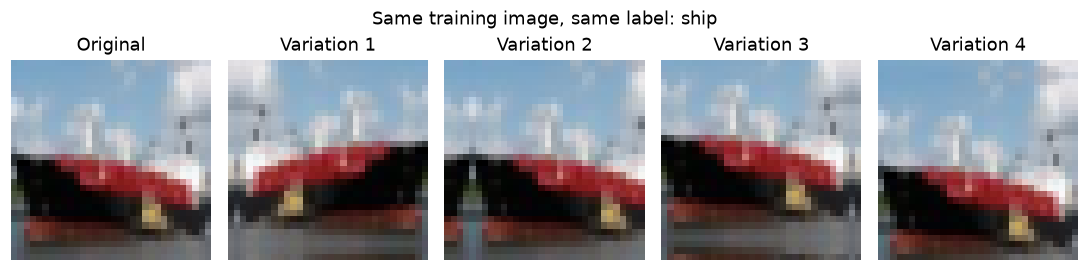

In [8]:
# 8. See how the same training image looks after random crops and flips.
preview_image, preview_label = raw_train[int(train_indices[0])]
fig, axes = plt.subplots(1, 5, figsize=(10, 2.5))
axes[0].imshow(preview_image)
axes[0].set_title("Original")
# just a preview; keep the training random sequence untouched
with torch.random.fork_rng(devices=[]):
    torch.manual_seed(seed)
    for index in range(1, 5):
        axes[index].imshow(augmentation(preview_image))
        axes[index].set_title(f"Variation {index}")
for ax in axes:
    ax.axis("off")
fig.suptitle(f"Same training image, same label: {classes[preview_label]}")
plt.tight_layout()
plt.show()

In [9]:
# 9. Give each split its own transform while sharing the raw images.
class DatasetView(Dataset):
    def __init__(self, source, indices, transform):
        self.source = source
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, index):
        image, label = self.source[int(self.indices[index])]
        return self.transform(image), label


train_dataset = DatasetView(raw_train, train_indices, train_transform)
val_dataset = DatasetView(raw_train, val_indices, eval_transform)
test_dataset = DatasetView(raw_test, np.arange(len(raw_test)), eval_transform)

# same val image twice should give exactly the same tensor
assert torch.equal(val_dataset[0][0], val_dataset[0][0])
print("One image:", val_dataset[0][0].shape)

One image: torch.Size([3, 32, 32])


In [10]:
# 10. Group images into batches and shuffle only the training data.
train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True,
    generator=torch.Generator().manual_seed(seed),
    num_workers=num_workers, pin_memory=(device.type == "cuda"),
)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

# separate preview batch, so we don't disturb the training shuffle
preview_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
with torch.random.fork_rng(devices=[]):
    torch.manual_seed(seed)
    images, labels = next(iter(preview_loader))

print("Images:", images.shape, "| Labels:", labels.shape)
print("Batches:", len(train_loader), "train,", len(val_loader), "val,", len(test_loader), "test")

Images: torch.Size([32, 3, 32, 32]) | Labels: torch.Size([32])
Batches: 1407 train, 157 val, 313 test


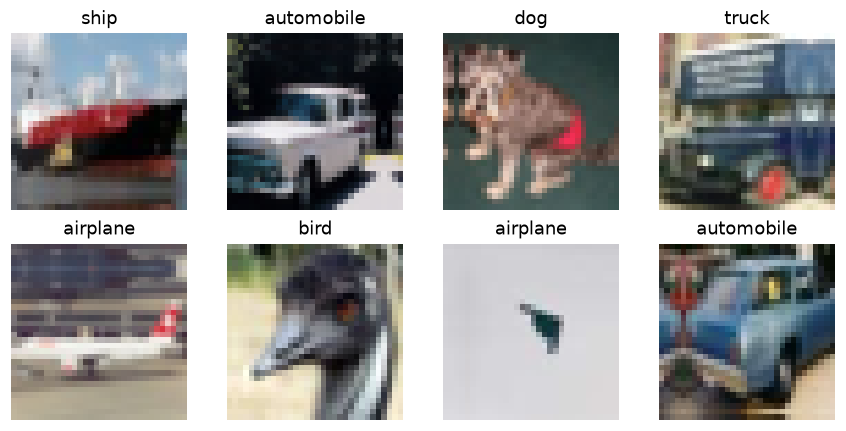

In [11]:
# 11. Undo normalization just for plotting a few images from a batch.
def image_for_display(img):
    mean_tensor = torch.tensor(mean).view(3, 1, 1)
    std_tensor = torch.tensor(std).view(3, 1, 1)
    img = img.detach().cpu() * std_tensor + mean_tensor  # undo normalization
    return img.clamp(0, 1).permute(1, 2, 0).numpy()


fig, axes = plt.subplots(2, 4, figsize=(8, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(image_for_display(images[i]))
    ax.set_title(classes[labels[i].item()])
    ax.axis("off")
plt.tight_layout()
plt.show()

In [12]:
# 12. Build an untrained MobileNet-v2 with 10 outputs and first stride = 1.
# Model reference: https://github.com/pytorch/vision/blob/main/torchvision/models/mobilenetv2.py
def build_mobilenet_v2(num_classes=10, width_mult=1.0, dropout=0.2):
    network = mobilenet_v2(
        weights=None,  # starting without pretrained weights
        num_classes=num_classes,
        width_mult=width_mult,
        dropout=dropout,
        norm_layer=partial(nn.BatchNorm2d, eps=1e-5, momentum=0.1),
    )
    # our images are tiny already, don't shrink them immediately
    network.features[0][0].stride = (1, 1)
    return network


torch.manual_seed(seed)
model = build_mobilenet_v2(num_classes, width_mult, dropout).to(device)
print("First conv:", model.features[0][0])
print("Classifier:", model.classifier)
print("\nOne block, just to see what's inside:\n", model.features[2])

First conv: Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
Classifier: Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=10, bias=True)
)

One block, just to see what's inside:
 InvertedResidual(
  (conv): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): Conv2dNormActivation(
      (0): Conv2d(96, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=96, bias=False)
      (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (2): Conv2d(96, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (3): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
)


In [13]:
# 13. Count parameters and estimate parameter + buffer storage in MB, not total GPU memory.
parameter_count = sum(p.numel() for p in model.parameters())
parameter_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
buffer_bytes = sum(b.numel() * b.element_size() for b in model.buffers())
model_tensor_bytes = parameter_bytes + buffer_bytes

print(f"Parameters: {parameter_count:,}")
print(f"Parameter storage: {parameter_bytes / 1e6:.4f} MB")
print(f"Buffers: {buffer_bytes / 1e6:.4f} MB")
print(f"Total tensor storage: {model_tensor_bytes / 1e6:.4f} MB")

Parameters: 2,236,682
Parameter storage: 8.9467 MB
Buffers: 0.1369 MB
Total tensor storage: 9.0836 MB


In [14]:
# 14. Chalo, follow one image through the layers and check the shapes.
model.eval()
with torch.no_grad():
    x = images[:1].to(device)
    print("Input:", tuple(x.shape))
    for i, layer in enumerate(model.features):
        x = layer(x)
        print(f"Block {i:2}: {tuple(x.shape)}")

    x = nn.functional.adaptive_avg_pool2d(x, (1, 1))
    print("After pooling:", tuple(x.shape))
    x = torch.flatten(x, 1)
    one_image_scores = model.classifier(x)
    print("Final scores:", tuple(one_image_scores.shape))

    # this manual walk should match model(image)
    torch.testing.assert_close(one_image_scores, model(images[:1].to(device)))

Input: (1, 3, 32, 32)


Block  0: (1, 32, 32, 32)


Block  1: (1, 16, 32, 32)
Block  2: (1, 24, 16, 16)
Block  3: (1, 24, 16, 16)
Block  4: (1, 32, 8, 8)
Block  5: (1, 32, 8, 8)
Block  6: (1, 32, 8, 8)


Block  7: (1, 64, 4, 4)
Block  8: (1, 64, 4, 4)
Block  9: (1, 64, 4, 4)
Block 10: (1, 64, 4, 4)
Block 11: (1, 96, 4, 4)
Block 12: (1, 96, 4, 4)
Block 13: (1, 96, 4, 4)
Block 14: (1, 160, 2, 2)
Block 15: (1, 160, 2, 2)
Block 16: (1, 160, 2, 2)
Block 17: (1, 320, 2, 2)
Block 18: (1, 1280, 2, 2)
After pooling: (1, 1280, 1, 1)
Final scores: (1, 10)


Output: torch.Size([32, 10])
First image probabilities: [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
Untrained batch loss: 2.3026


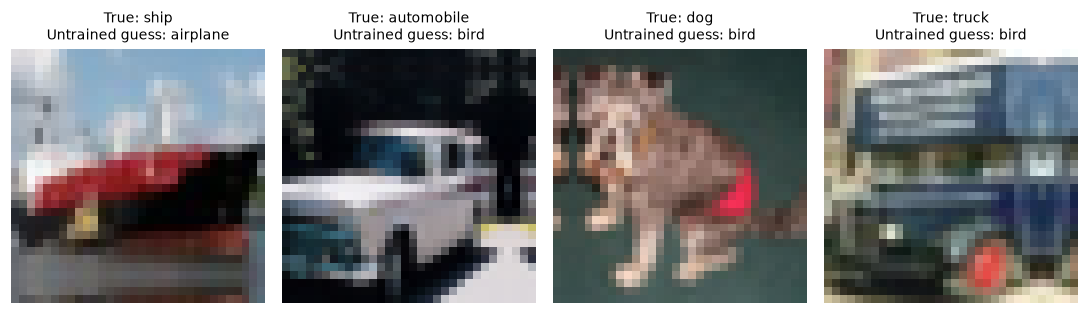

In [15]:
# 15. Check one batch of scores and loss; these untrained guesses are not baseline accuracy.
model.eval()
criterion = nn.CrossEntropyLoss()

with torch.no_grad():
    logits = model(images.to(device))
    probabilities = logits.softmax(dim=1)
    predicted_labels = logits.argmax(dim=1)
    initial_loss = criterion(logits, labels.to(device))

assert logits.shape == (batch_size, num_classes)
assert torch.isfinite(logits).all() and torch.isfinite(initial_loss)
print("Output:", logits.shape)
print("First image probabilities:", probabilities[0].cpu().numpy().round(3))
print(f"Untrained batch loss: {initial_loss.item():.4f}")

# no learning yet, so don't judge these guesses :)
fig, axes = plt.subplots(1, 4, figsize=(10, 2.8))
for i, ax in enumerate(axes):
    actual = classes[labels[i].item()]
    guess = classes[predicted_labels[i].item()]
    ax.imshow(image_for_display(images[i]))
    ax.set_title(f"True: {actual}\nUntrained guess: {guess}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [16]:
# 16. Save the splits and settings for training/report writing later, not trained weights.
package_names = ["torch", "torchvision", "numpy", "matplotlib", "pillow", "ipykernel", "nbformat", "nbclient"]
package_versions = {name: version(name) for name in package_names}

preparation_config = {
    "seed": seed,
    "dataset": "CIFAR-10",
    "image_size": image_size,
    "classes": classes,
    "splits": {"train": len(train_dataset), "validation": len(val_dataset), "test": len(test_dataset)},
    "split_method": "seeded permutation within each class; 500 validation examples per class",
    "normalization": {"mean": mean, "std": std, "computed_from": "training split only, before augmentation"},
    "training_augmentation": {"random_crop_size": image_size, "padding": 4, "padding_mode": "reflect", "horizontal_flip_probability": 0.5},
    "loader": {"batch_size": batch_size, "num_workers": num_workers},
    "model": {
        "architecture": "MobileNet-v2",
        "pretrained": False,
        "num_classes": num_classes,
        "width_mult": width_mult,
        "dropout": dropout,
        "first_convolution_stride": 1,
        "other_stage_strides": "torchvision defaults",
        "batch_norm_eps": 1e-5,
        "batch_norm_momentum": 0.1,
        "parameter_count": parameter_count,
        "uncompressed_tensor_bytes": model_tensor_bytes,
    },
    "python": platform.python_version(),
    "packages": package_versions,
}

np.savez(save_dir / "split_indices.npz", train=train_indices, validation=val_indices)
config_path = save_dir / "config.json"
config_path.write_text(json.dumps(preparation_config, indent=2) + "\n", encoding="utf-8")
print("Saved:", config_path.relative_to(project_dir))
print("Saved:", (save_dir / "split_indices.npz").relative_to(project_dir))

Saved: artifacts\preparation\config.json
Saved: artifacts\preparation\split_indices.npz


In [ ]:
# 17. The 300-epoch loop runs separately in train_baseline.py.
# This cell only shows the plan; it doesn't start a second training job.
# To resume after an interruption, run in PowerShell: .\start_training.ps1 -Resume
from train_baseline import DEFAULT_RUN
run_dir = DEFAULT_RUN
print("Epochs: 300 | Batch: 128 | SGD + momentum | Mixed precision for training")
print("LR: 0.1, 5 warm-up epochs, then cosine decay to 0.00001")
print("Random crops/flips + small erased patches, weight decay and label smoothing")
print("Best checkpoint is picked using validation accuracy. Test only after training.")
print("Run folder:", run_dir)

In [ ]:
# 18. Re-run this cell whenever you want a quick progress update.
from train_baseline import training_is_running
status_path = run_dir / "status.json"
if status_path.exists():
    progress = json.loads(status_path.read_text())
    print("State:", progress["state"], "| Process active:", training_is_running(run_dir))
    print("Epoch:", progress["epoch"], "/", progress["total_epochs"])
    print("Phase:", progress.get("phase"), "| Batch:", progress.get("batch", 0), "/", progress.get("batches", 0))
    print("Best val accuracy:", progress.get("best_val_accuracy", 0), "%")
    if "estimated_hours_remaining" in progress:
        print("Approx hours left:", round(progress["estimated_hours_remaining"], 2))
    if "error" in progress:
        print("Error:", progress["error"])
else:
    print("Training is still starting; check again in a bit.")

In [ ]:
# 19. Plot the finished epochs. The CSV grows while training runs.
import csv
history_path = run_dir / "history.csv"
if history_path.exists():
    with history_path.open(newline="") as f:
        history = list(csv.DictReader(f))
    epochs_done = [int(row["epoch"]) for row in history]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for split in ["train", "val"]:
        axes[0].plot(epochs_done, [float(row[f"{split}_loss"]) for row in history], label=split)
        axes[1].plot(epochs_done, [float(row[f"{split}_accuracy"]) for row in history], label=split)
    axes[0].set_ylabel("Loss (label smoothing 0.05)")
    axes[1].set_ylabel("Accuracy (%)")
    for ax in axes:
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    print("Let the first epoch finish, then we'll have something to plot.")

In [ ]:
# 20. Once training is done, load the best model for the compression part.
# Final test accuracy is written by the training script, not used for tuning.
from train_baseline import build_model
results_path = run_dir / "results.json"
if results_path.exists():
    results = json.loads(results_path.read_text())
    print("Best epoch:", results["best_epoch"])
    print("Validation accuracy:", results["best_validation_accuracy"], "%")
    print("Final test accuracy:", results["test_accuracy"], "%")
    checkpoint = torch.load(run_dir / "best.pt", map_location=device, weights_only=False)
    baseline_model = build_model(checkpoint["config"]["preparation"]["model"]).to(device)
    baseline_model.load_state_dict(checkpoint["model"])
    baseline_model.eval()
    print("Trained baseline loaded. Compression comes next.")
else:
    print("Training isn't finished yet. We haven't evaluated the test set.")

In [ ]:
# 21. A tiny example: fewer bits give fewer possible weight values.
import json
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
from manual_compression import quantize_weight, pack_codes, unpack_codes

toy_weights = torch.tensor([[-1.0, -0.44, 0.0, 0.33, 0.78, 1.0]])
print("Original:", toy_weights.numpy().round(3))
for bits in [8, 4, 2]:
    rounded, details = quantize_weight(toy_weights, bits)
    print(f"{bits}-bit:  ", rounded.numpy().round(3))


In [ ]:
# 22. Bas, two 4-bit codes can share one byte. Odd counts need a little padding.
small_codes = np.array([1, 2, 15], dtype=np.uint8)
packed = pack_codes(small_codes, bits=4)
unpacked = unpack_codes(packed, bits=4, count=len(small_codes))
print("Codes:", small_codes)
print("Packed bytes:", list(packed), "| bytes used:", len(packed))
print("Restored:", unpacked)
assert np.array_equal(small_codes, unpacked)


In [ ]:
# 23. Read the saved CPU preview. These are interim results on only 200 val images.
preview_folder = Path("artifacts/compression/preview_initial")
preview_result = json.loads((preview_folder / "results.json").read_text())
print("Checkpoint epoch:", preview_result["baseline_epoch"])
print("Calibration images:", preview_result["calibration_images"], "(training split)")
print("Validation images:", preview_result["validation_images"], "| test images used: 0")
print("First conv + classifier stay FP32. W = weight bits, A = activation bits.\n")
print(f"{'Setting':<10} {'Val acc':>9} {'Model MB':>10} {'Storage ratio':>15} {'Act. estimate':>15}")
for row in preview_result["rows"]:
    print(f"{row['setting']:<10} {row['validation_accuracy']:>8.2f}% "
          f"{row['model_size_mb']:>10.3f} {row['weight_compression_ratio']:>14.2f}x "
          f"{row['activation_compression_ratio']:>14.2f}x")
print("\nPacked model size is measured; activation storage is an estimate, not GPU memory.")


In [ ]:
# 24. Compare accuracy and saved size. Don't use this small preview as the final result.
rows = preview_result["rows"]
labels = [row["setting"] for row in rows]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
bars = axes[0].bar(labels, [row["validation_accuracy"] for row in rows], color="steelblue")
axes[0].bar_label(bars, fmt="%.1f%%", padding=3)
axes[0].set_ylabel("Validation accuracy (%)")
axes[0].set_ylim(0, 100)
bars = axes[1].bar(labels, [row["model_size_mb"] for row in rows], color="darkorange")
axes[1].bar_label(bars, fmt="%.2f", padding=3)
axes[1].set_ylabel("Model storage (MB)")
axes[1].set_ylim(0, max(row["model_size_mb"] for row in rows) * 1.18)
fig.suptitle(f"Preview only: epoch {preview_result['baseline_epoch']}, {preview_result['validation_images']} validation images")
fig.tight_layout()
fig.savefig(preview_folder / "comparison.png", dpi=150)
plt.show()


In [ ]:
# 25. Change these settings to try another small CPU preview while training continues.
from run_compression import run_experiments
compression_settings = [(8, 8), (4, 8), (4, 4)]
run_new_preview = False  # set True when you actually want another experiment

if run_new_preview:
    preview_folder, preview_result = run_experiments(
        preview=True, device="cpu", settings=compression_settings,
        calibration_per_class=10, validation_per_class=20,
        keep_first_last=True, fold_bn=True,
    )
    # Re-run cell 24 to plot this new result; cell 23 reloads the original preview.
else:
    print("Preview controls ready. The saved results above came from a real CPU run.")


In [ ]:
# 26. After baseline training finishes, compare settings on all 5000 validation images.
# Keep this off during Run All; the full sweep is a separate experiment.
run_full_sweep = False
if run_full_sweep:
    full_folder, full_result = run_experiments(
        preview=False, device="cuda", batch_size=128,
        settings=compression_settings, calibration_per_class=100,
        validation_per_class=500, keep_first_last=True, fold_bn=True,
    )
    print("Full validation results:", full_folder)
else:
    print("Full sweep pending. Final test evaluation and the W&B chart come afterwards.")
